# COMP316 – LSTM Sentiment Classifier
**Steam Reviews Dataset**


## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to wherever you put the CSV files in your Drive
DATA_PATH = '/content/drive/MyDrive/COMP316_Project_CleanedData'

Mounted at /content/drive


## 2. Install & Import

In [ ]:
!pip install nltk tensorflow pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import re
import time
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense,
    Dropout, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from nltk.corpus import stopwords
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

nltk.download('stopwords', quiet=True)

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
print('All imports successful.')

TensorFlow version: 2.20.0
GPU available: True
All imports successful.


## 3. Load Data

In [ ]:
train_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_train_FINAL.csv', encoding='utf-8-sig')
test_no_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_NO_SENTIMENT_FINAL.csv', encoding='utf-8-sig')
test_with_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_WITH_SENTIMENT_FINAL.csv', encoding='utf-8-sig')

print('Train shape:', train_df.shape)
print('Test (no sentiment) shape:', test_no_sent_df.shape)
print('Test (with sentiment) shape:', test_with_sent_df.shape)
print()
print('Sentiment distribution in train:')
print(train_df['sentiment'].value_counts())
train_df.head(3)

Train shape: (42000, 5)
Test (no sentiment) shape: (18000, 4)
Test (with sentiment) shape: (18000, 5)

Sentiment distribution in train:
sentiment
1    21000
0    21000
Name: count, dtype: int64


,review_id,app_id,review_text,sentiment,helpful_score
0,1,4000,I remember watching so much content based arou...,1,0.50000
1,2,489830,"man i love this game, i grew up with it (i did...",0,0.50000
2,3,8870,You know the storyline is marvelous when you w...,1,0.52381


## 4. Text Preprocessing
Light cleaning only — LSTM benefits from word order so we don't stem.

In [ ]:
stop_words = set(stopwords.words('english'))
# Keep negations — they're crucial for sentiment
negations = {'not', 'no', 'nor', 'never', "don't", "doesn't", "didn't",
             "won't", "wouldn't", "can't", "couldn't", "shouldn't",
             "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't"}
stop_words = stop_words - negations

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

print('Preprocessing training data...')
start = time.time()
train_df['clean_text'] = train_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

print('Preprocessing test data...')
start = time.time()
test_no_sent_df['clean_text'] = test_no_sent_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

# Drop empty reviews after preprocessing
before = len(train_df)
train_df = train_df[train_df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f'\nDropped {before - len(train_df)} empty training reviews after preprocessing')

print('\nSample before/after:')
print('BEFORE:', train_df['review_text'].iloc[0][:200])
print('AFTER: ', train_df['clean_text'].iloc[0][:200])

# Quick stats on review lengths
lengths = train_df['clean_text'].str.split().str.len()
print(f'\nReview length stats:')
print(f'  Mean:   {lengths.mean():.1f} tokens')
print(f'  Median: {lengths.median():.0f} tokens')
print(f'  90th %: {lengths.quantile(0.9):.0f} tokens')
print(f'  Max:    {lengths.max()} tokens')

Preprocessing training data...
Done in 2.6s
Preprocessing test data...
Done in 1.5s

Dropped 54 empty training reviews after preprocessing

Sample before/after:
BEFORE: I remember watching so much content based around this game throughout my childhood and wishing how I could get my hands on it as a kid...And buying it now in 2026?

I don't regret buying this game, 
AFTER:  remember watching much content based around game throughout childhood wishing could get hands kid buying regret buying game funny wholesome moments play friends addons get marketplace also make much b

Review length stats:
  Mean:   26.7 tokens
  Median: 10 tokens
  90th %: 63 tokens
  Max:    933 tokens


## 5. Tokenization & Padding

In [ ]:
MAX_VOCAB = 30000   # vocabulary size
MAX_LEN   = 150     # most reviews fit comfortably in 150 tokens

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

actual_vocab = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Total unique words found: {len(tokenizer.word_index):,}')
print(f'Using vocab size: {actual_vocab:,}')

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_no_sent_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

y_train = train_df['sentiment'].values.astype('float32')
y_test_true = test_with_sent_df.set_index('review_id').loc[test_no_sent_df['review_id']]['sentiment'].values

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train balance: {np.bincount(y_train.astype(int))}')

Total unique words found: 36,129
Using vocab size: 30,000

X_train shape: (41946, 150)
X_test shape:  (18000, 150)
y_train balance: [20981 20965]


In [ ]:
EMBED_DIM  = 128
LSTM_UNITS = 64

model = Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    Embedding(input_dim=actual_vocab, output_dim=EMBED_DIM, mask_zero=False),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=1e-3, clipnorm=1.0)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=1,
    min_lr=1e-6, verbose=1
)

print('Training Bidirectional LSTM...')
start = time.time()

history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

training_time = time.time() - start
print(f'\nTraining complete in {training_time:.1f}s ({training_time/60:.1f} min)')

Training Bidirectional LSTM...
Epoch 1/8
295/295 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7883 - loss: 0.4454 - val_accuracy: 0.8458 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 2/8
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8654 - loss: 0.3223
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8763 - loss: 0.3030 - val_accuracy: 0.8482 - val_loss: 0.3661 - learning_rate: 0.0010
Epoch 3/8
293/295 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8997 - loss: 0.2523
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9117 - loss: 0.2295 - val_accuracy: 0.8474 - val_loss: 0.3879 - learning_rate: 5.0000e-04
Epoch 4/8
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9207 - loss: 0.2126
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step 

## 8. Training History Plot

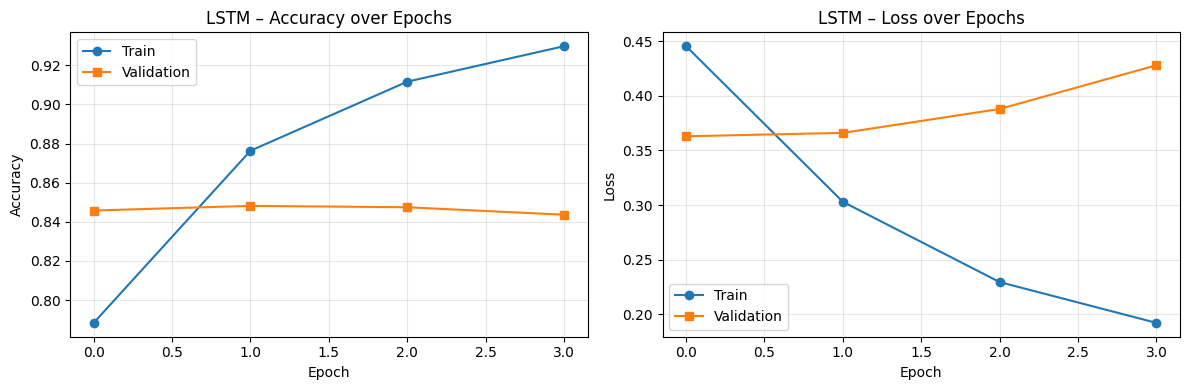

Saved as lstm_training_history.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], marker='o', label='Train')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation')
ax1.set_title('LSTM – Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], marker='o', label='Train')
ax2.plot(history.history['val_loss'], marker='s', label='Validation')
ax2.set_title('LSTM – Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()
print('Saved as lstm_training_history.png')

## 9. Predict on Test Set

In [ ]:
print('Generating predictions...')
start = time.time()
y_prob = model.predict(X_test, batch_size=256, verbose=1)
y_pred = (y_prob >= 0.5).astype(int).flatten()
inference_time = time.time() - start
print(f'Inference complete in {inference_time:.2f}s')

results_df = test_no_sent_df[['review_id']].copy()
results_df['predicted_sentiment'] = y_pred
results_df['true_sentiment'] = y_test_true
print('\nPrediction distribution:')
print(pd.Series(y_pred).value_counts())
results_df.head(10)

Generating predictions...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Inference complete in 1.05s

Prediction distribution:
0    9481
1    8519
Name: count, dtype: int64


,review_id,predicted_sentiment,true_sentiment
0,1,0,0
1,2,1,1
2,3,1,1
3,4,0,0
4,5,0,0
5,6,1,1
6,7,1,1
7,8,0,0
8,9,1,1
9,10,1,1


## 10. Evaluate the Model

In [ ]:
acc       = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred)
recall    = recall_score(y_test_true, y_pred)
f1        = f1_score(y_test_true, y_pred)

print('='*45)
print('        LSTM EVALUATION RESULTS')
print('='*45)
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision: {precision:.4f}')
print(f'  Recall   : {recall:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  Train Time: {training_time:.1f}s ({training_time/60:.1f} min)')
print(f'  Inference: {inference_time:.2f}s ({len(y_pred)} reviews)')
print('='*45)
print()
print('Full Classification Report:')
print(classification_report(y_test_true, y_pred, target_names=['Negative (0)', 'Positive (1)']))

        LSTM EVALUATION RESULTS
  Accuracy : 0.8405  (84.05%)
  Precision: 0.8597
  Recall   : 0.8138
  F1-Score : 0.8361
  Train Time: 35.0s (0.6 min)
  Inference: 1.05s (18000 reviews)

Full Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.87      0.84      9000
Positive (1)       0.86      0.81      0.84      9000

    accuracy                           0.84     18000
   macro avg       0.84      0.84      0.84     18000
weighted avg       0.84      0.84      0.84     18000



## 11. Confusion Matrix

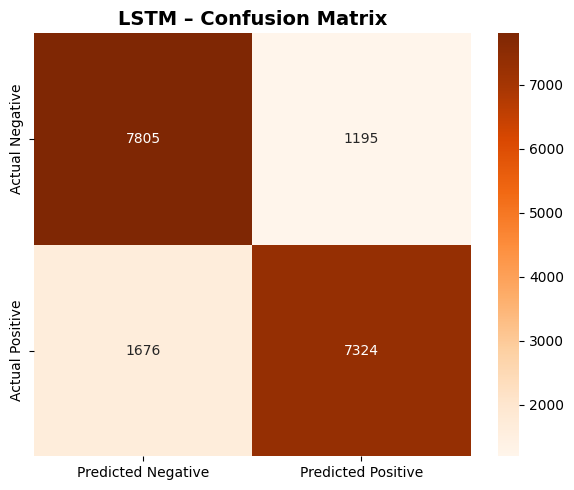

Saved as lstm_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)
plt.title('LSTM – Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()
print('Saved as lstm_confusion_matrix.png')

## 12. Save Results

In [ ]:
results_df.to_csv('lstm_predictions.csv', index=False, encoding='utf-8-sig')
print('Predictions saved to lstm_predictions.csv')

metrics_df = pd.DataFrame([{
    'Model': 'LSTM',
    'Accuracy': round(acc, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1_Score': round(f1, 4),
    'Train_Time_s': round(training_time, 2),
    'Inference_Time_s': round(inference_time, 2)
}])
metrics_df.to_csv('lstm_metrics.csv', index=False)
print('Metrics saved to lstm_metrics.csv')
metrics_df

Predictions saved to lstm_predictions.csv
Metrics saved to lstm_metrics.csv


,Model,Accuracy,Precision,Recall,F1_Score,Train_Time_s,Inference_Time_s
0,LSTM,0.8405,0.8597,0.8138,0.8361,35.04,1.05
